# Emulation and Visualization

The point of this notebook is to be able to emulate and visualize data using existing models 

In [1]:
from __future__ import annotations

import json
import yaml
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display, HTML

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "PROJECT_EXPERIMENT_GUIDE.md").exists() and (candidate / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find the XLZD repo root from the current working directory.")

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

if str(REPO_ROOT / "xlzd_shell") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "xlzd_shell"))

from visualize import find_shells, plot_input_points_3d, plot_cnp_pred_shell_occupancy
from emulation import emulate_detector_points, predict_cnp_from_emulated_csv
from prepare_shell_data import ShellConfig
from cnp_clean_pipeline import load_runtime_config

DATA_PATH = REPO_ROOT / "data"
EMULATED_DATA_PATH = DATA_PATH / "emulated"
OUTPUT_PATH = REPO_ROOT / "shell_outputs"
OUTPUT_PLOTS_PATH = OUTPUT_PATH / "plots"
CONFIG_PATH = REPO_ROOT / "xlzd_shell" / "config" / "settings_shell_minibatch.yaml"
MODEL_PATH = REPO_ROOT / "data" / "out" / "cnp" / "cnp_xlzd_shell_v1_minibatch_model_15epochs.pth"

In [2]:
# Use this cell to set pre-chosen values of the detector
params = {
    "z_max": 2000,    # Half the height of the detector
    "r_max": 1500,    # Radius of the detector
    "width": 100,      # "Skin" width to create points
    "num_points": 5e5, # Number of points to emulate
    "nshells": 100,    # Number of shells
}

pd.DataFrame({
    "parameter": list(params.keys()),
    "value": list(params.values()),
})

,parameter,value
0,z_max,2000.0
1,r_max,1500.0
2,width,100.0
3,num_points,500000.0
4,nshells,100.0


# Emulation
Emulate a set of fake data based off detector parameters. Plot these points on an interactive HTML to check it looks good.

In [3]:
# First emulate the data
emulated_df = emulate_detector_points(
    n_points=params["num_points"],
    radius=params["r_max"],
    height=2*params["z_max"],
    width=params["width"]
)

# Save to a csv
emulated_data_csv = EMULATED_DATA_PATH / f"emulated_data_{int(params["num_points"])}points.csv"
emulated_data_plot = OUTPUT_PLOTS_PATH / "emulated_data_points.html"

emulated_data_csv.parent.mkdir(parents=True, exist_ok=True)
emulated_data_plot.parent.mkdir(parents=True, exist_ok=True)
emulated_df.to_csv(emulated_data_csv)

# Save a plot output of the emulated data
plot_input_points_3d(
    inpath = emulated_data_csv,
    outpath = emulated_data_plot,
    )

# Display the HTML
display(HTML(filename=emulated_data_plot))

# Prediction
Predict outputs based on the above emulated data and output shell plots

Plots the occupancy of these predictions (Plotted truth values are fake)

In [4]:
shell_cfg = ShellConfig(
    R_max = params["r_max"],
    Z_max = params["z_max"],
    n_shells = params["nshells"],
    z_center = None
)
runtime = load_runtime_config(
    config_path = CONFIG_PATH,
    seed=42,
)

pred_results = predict_cnp_from_emulated_csv(
    emulated_csv=emulated_data_csv,
    runtime=runtime,
    model_path=MODEL_PATH,
    output_dir=OUTPUT_PATH,
    shell_cfg=shell_cfg,
    h5_block_size=50000,
)


Starting CNP prediction
MFGP CSV:       /home/liuser/pknauss/XLZD/shell_outputs/cnp_xlzd_shell_v1_minibatch_emulated_data_500000points_event_shell_distribution_15epochs.csv
All-shell CSV:  /home/liuser/pknauss/XLZD/shell_outputs/cnp_xlzd_shell_v1_minibatch_emulated_data_500000points_event_shell_distribution_15epochs_all_shells.csv
Best-shell CSV: /home/liuser/pknauss/XLZD/shell_outputs/cnp_xlzd_shell_v1_minibatch_emulated_data_500000points_event_shell_distribution_15epochs_best_shell.csv


UNKNOWN:   0%|          | 0/10 [00:00<?, ?block/s]

Saved MFGP compatable CNP CSV: /home/liuser/pknauss/XLZD/shell_outputs/cnp_xlzd_shell_v1_minibatch_emulated_data_500000points_event_shell_distribution_15epochs.csv
Saved all event-shell probabilities: /home/liuser/pknauss/XLZD/shell_outputs/cnp_xlzd_shell_v1_minibatch_emulated_data_500000points_event_shell_distribution_15epochs_all_shells.csv
Saved best shell per event: /home/liuser/pknauss/XLZD/shell_outputs/cnp_xlzd_shell_v1_minibatch_emulated_data_500000points_event_shell_distribution_15epochs_best_shell.csv


(<Figure size 1200x400 with 1 Axes>,
 [<Axes: title={'center': 'Predicted Shell Distribution'}, xlabel='Shell Number', ylabel='Count'>])

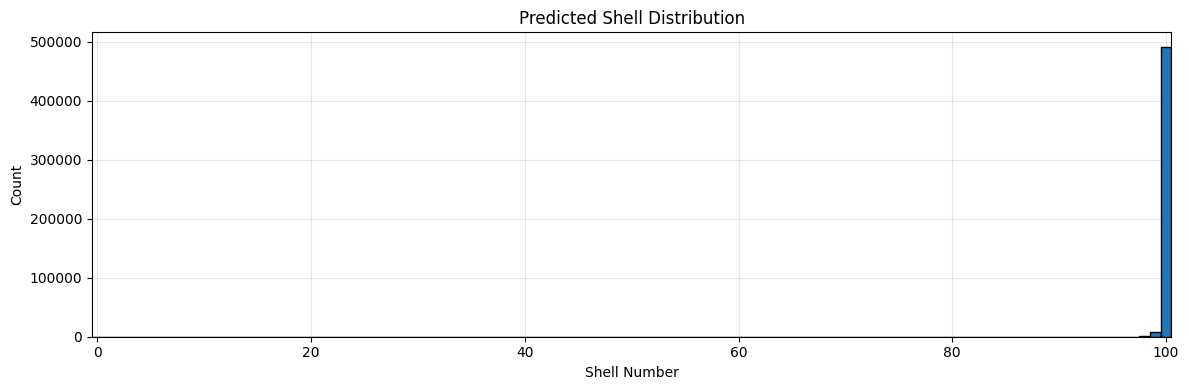

In [5]:
plot_cnp_pred_shell_occupancy(pred_results)